# 03. Matching

Matching is one of the most intuitive tools in observational causal inference. The idea is simple:

> For each treated unit, find one or more untreated units that looked similar before treatment.

Then compare outcomes inside those constructed comparisons.

In industry settings, matching is often easy to explain. If a retention team contacted high-risk customers, we look for similar high-risk customers who were not contacted. If a sales team offered a discount to some accounts, we look for similar accounts that did not receive the discount. If a product team rolled out a feature to selected users, we look for comparable users who did not get it.

But the simplicity is also risky. A matched pair becomes a credible causal comparison only when it improves the design: better covariate balance, credible overlap, and a clearly defined target population.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain matching as a design-stage procedure for observational causal inference.
- Distinguish ATE and ATT, and explain why matching often targets the ATT.
- Implement nearest-neighbor matching with replacement.
- Add propensity-score calipers and exact matching constraints.
- Compute matched ATT estimates from matched pairs or matched sets.
- Diagnose matched-sample balance using standardized mean differences.
- Explain the tradeoffs among replacement, calipers, and matching ratio.
- Recognize why propensity-score matching can fail even when propensity scores are useful.
- Describe how matching can be combined with outcome modeling after preprocessing.

## Mathematical Setup: Matching as Design Before Estimation

Matching tries to approximate the comparison that a randomized experiment would have produced. The usual target is the average treatment effect for treated units:

$$
\tau_{ATT} = E[Y(1) - Y(0) \mid D=1]
$$

For each treated unit $i$, choose a set of matched comparison units $\mathcal{M}(i)$ using covariates or a propensity score. A nearest-neighbor distance can be written as:

$$
d(i,j) = \lVert X_i - X_j \rVert
$$

After matching, the ATT estimator is:

$$
\widehat{\tau}_{ATT} = \frac{1}{n_T}\sum_{i:D_i=1}\left(Y_i - \frac{1}{|\mathcal{M}(i)|}\sum_{j \in \mathcal{M}(i)}Y_j\right)
$$

The matching step is a design step. The analyst should inspect balance before trusting the outcome contrast. Matching with poor balance is only a complicated treated-versus-control comparison.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.special import expit, logit
from sklearn.neighbors import NearestNeighbors
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr("node", shape="box", style="rounded,filled", fontname="DejaVu Sans", fontsize="11", margin="0.12,0.08", color="#334155")
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def weighted_mean_and_var(x, w):
    """Compute a weighted mean and variance for balance diagnostics.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        w: Weight vector used for weighted summaries.

    Returns:
        tuple: Weighted mean and weighted variance.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def standardized_mean_differences(frame, covariates, treatment="treated", weights=None):
    """
    Compute standardized mean differences for pre-treatment covariates.
    
    Idea:
        SMDs put covariate imbalance on a common scale so diagnostics can be compared before and after adjustment or weighting.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        covariates: Pre-treatment covariate columns evaluated for balance or adjustment.
        treatment: Treatment column or treatment value used to define the causal contrast.
        weights: Optional observation weights defining the adjusted pseudo-population.
    
    Returns:
        pandas.DataFrame: Balance diagnostics for each covariate, including treated and comparison summaries.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    rows = []
    for col in covariates:
        x = frame[col].to_numpy(dtype=float)
        mt, vt = weighted_mean_and_var(x[treated], weights[treated])
        mc, vc = weighted_mean_and_var(x[~treated], weights[~treated])
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def plot_smd_comparison(balance_tables, title, threshold=0.10):
    """Plot standardized mean differences across design choices.

    Args:
        balance_tables: Collection of balance tables to compare across designs.
        title: Title shown on the resulting figure.
        threshold: Diagnostic threshold used to flag imbalance.

    Returns:
        tuple: Matplotlib figure and axes for SMD comparison.
    """
    plot_df = pd.concat(
        [table.assign(source=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = plot_df.groupby("covariate")["abs_smd"].max().sort_values(ascending=True).index
    fig, ax = plt.subplots(figsize=(8.8, max(4.2, 0.36 * len(order))))
    sns.scatterplot(
        data=plot_df,
        x="smd",
        y="covariate",
        hue="source",
        style="source",
        s=75,
        ax=ax,
        zorder=3,
    )
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()


def nearest_neighbor_match(
    frame,
    match_cols,
    ratio=1,
    caliper_col=None,
    caliper=None,
    exact_cols=None,
    treatment="treated",
):
    """
    Match treated units to nearby comparison units on selected covariates or scores.
    
    Idea:
        Matching constructs a comparison group that resembles treated units before estimating an ATT-style contrast.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        match_cols: Covariate or score columns used to compute nearest-neighbor distances.
        ratio: Number of comparison units matched to each treated unit.
        caliper_col: Optional column used to enforce maximum acceptable matching distance.
        caliper: Maximum allowed distance on the caliper column.
        exact_cols: Columns that must match exactly before nearest-neighbor matching is attempted.
        treatment: Treatment column or treatment value used to define the causal contrast.
    
    Returns:
        pandas.DataFrame: Matched treated-control pairs with distances and matched unit identifiers.
    """
    exact_cols = exact_cols or []
    pairs = []

    if exact_cols:
        groups = frame[exact_cols].drop_duplicates().to_dict("records")
    else:
        groups = [{}]

    for group in groups:
        if group:
            mask = np.ones(len(frame), dtype=bool)
            for col, val in group.items():
                mask &= frame[col].to_numpy() == val
            sub = frame.loc[mask]
        else:
            sub = frame

        treated_units = sub[sub[treatment] == 1]
        control_units = sub[sub[treatment] == 0]
        if treated_units.empty or control_units.empty:
            continue

        search_neighbors = min(max(ratio * 20, ratio), len(control_units))
        nn = NearestNeighbors(n_neighbors=search_neighbors)
        nn.fit(control_units[match_cols].to_numpy(dtype=float))
        distances, indices = nn.kneighbors(treated_units[match_cols].to_numpy(dtype=float))

        control_index = control_units.index.to_numpy()
        treated_index = treated_units.index.to_numpy()

        for row_id, treated_id in enumerate(treated_index):
            selected = 0
            for neighbor_position, distance in zip(indices[row_id], distances[row_id]):
                control_id = control_index[neighbor_position]
                if caliper_col is not None and caliper is not None:
                    gap = abs(frame.loc[treated_id, caliper_col] - frame.loc[control_id, caliper_col])
                    if gap > caliper:
                        continue
                pairs.append({
                    "treated_index": treated_id,
                    "control_index": control_id,
                    "distance": float(distance),
                    "treated_outcome": frame.loc[treated_id, "outcome"],
                    "control_outcome": frame.loc[control_id, "outcome"],
                    "treated_score": frame.loc[treated_id, "ps"],
                    "control_score": frame.loc[control_id, "ps"],
                })
                selected += 1
                if selected >= ratio:
                    break

    return pd.DataFrame(pairs)


def summarize_matched_pairs(frame, pairs, label):
    """
    Summarize the treatment effect and diagnostics from matched pairs.
    
    Idea:
        The function reports the matched ATT estimate together with practical diagnostics such as matched sample size and distance.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        pairs: Matched treated-control pair table produced by the matching helper.
        label: Readable label attached to the model, matched design, or diagnostic row.
    
    Returns:
        dict: Matched-design estimate, sample counts, and distance summaries.
    """
    matched_sets = (
        pairs.groupby("treated_index")
        .agg(
            treated_outcome=("treated_outcome", "first"),
            matched_control_outcome=("control_outcome", "mean"),
            matches=("control_index", "size"),
            mean_distance=("distance", "mean"),
        )
        .reset_index()
    )
    matched_sets["pair_effect"] = matched_sets["treated_outcome"] - matched_sets["matched_control_outcome"]
    estimate = matched_sets["pair_effect"].mean()
    se = matched_sets["pair_effect"].std(ddof=1) / np.sqrt(len(matched_sets))
    true_matched_att = frame.loc[matched_sets["treated_index"], "true_individual_effect"].mean()
    return {
        "design": label,
        "matched_treated": len(matched_sets),
        "share_treated_matched": len(matched_sets) / frame["treated"].sum(),
        "matched_control_rows": len(pairs),
        "unique_controls_used": pairs["control_index"].nunique(),
        "mean_matches_per_treated": matched_sets["matches"].mean(),
        "att_hat": estimate,
        "paired_se_teaching_approx": se,
        "ci_low_teaching_approx": estimate - 1.96 * se,
        "ci_high_teaching_approx": estimate + 1.96 * se,
        "true_att_for_matched_treated": true_matched_att,
        "bias_vs_matched_att": estimate - true_matched_att,
        "mean_match_distance": pairs["distance"].mean(),
        "p95_match_distance": pairs["distance"].quantile(0.95),
    }


def matching_weights(frame, pairs, ratio=1):
    """
    Convert matched pairs into ATT-style observation weights.
    
    Idea:
        Weights allow the matched design to reuse the same balance and outcome summaries used elsewhere in the notebook.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        pairs: Matched treated-control pair table produced by the matching helper.
        ratio: Number of comparison units matched to each treated unit.
    
    Returns:
        pandas.Series: Observation weights for treated units and their matched controls.
    """
    weights = np.zeros(len(frame))
    matched_treated = pairs["treated_index"].drop_duplicates().to_numpy()
    weights[matched_treated] = 1.0
    for control_id in pairs["control_index"]:
        weights[control_id] += 1.0 / ratio
    return weights

## 1. Matching as Design

Matching tries to construct a comparison group that looks like the treated group before treatment. Stuart (2010) describes matching as a way to approximate the covariate balance that randomized experiments provide automatically. Ho, Imai, King, and Stuart (2007) frame matching as preprocessing that can reduce dependence on later parametric modeling choices.

The workflow is deliberately design-first:

1. Define the treatment, outcome, covariates, and estimand.
2. Match treated and untreated units using only pre-treatment variables.
3. Check balance and overlap.
4. Only then compare outcomes.

Matching should feel less like "running a model" and more like building a credible comparison set.

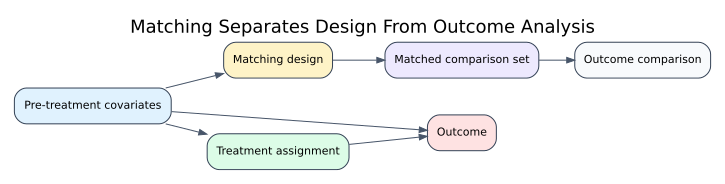

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
matching_edges = [
    ("Pre-treatment covariates", "Treatment assignment"),
    ("Pre-treatment covariates", "Outcome"),
    ("Treatment assignment", "Outcome"),
    ("Pre-treatment covariates", "Matching design"),
    ("Matching design", "Matched comparison set"),
    ("Matched comparison set", "Outcome comparison"),
]

matching_colors = {
    "Pre-treatment covariates": "#e0f2fe",
    "Treatment assignment": "#dcfce7",
    "Outcome": "#fee2e2",
    "Matching design": "#fef3c7",
    "Matched comparison set": "#ede9fe",
    "Outcome comparison": "#f8fafc",
}

smart_display(make_dag(matching_edges, "Matching Separates Design From Outcome Analysis", matching_colors))

The design step should not use the outcome. If we choose matches after looking at which matches produce the desired effect estimate, we have turned design into outcome fishing.

A good matching analysis should be able to show balance tables and matched-sample diagnostics before revealing the outcome result.

## 2. The Estimand: Matching Often Targets ATT

Regression adjustment and weighting can target different estimands. Matching is often most naturally aligned with the average treatment effect on the treated:

$$
ATT = E[Y(1) - Y(0) \mid D=1]
$$

Why ATT? Because nearest-neighbor matching often starts with treated units and asks:

> For the treated units we actually intervened on, what would have happened if they had not been treated?

A matched ATT estimator with one matched control per treated unit is:

$$
\widehat{ATT}_{match} = \frac{1}{N_M}\sum_{i:D_i=1, i \in M}\left(Y_i - Y_{m(i)}\right)
$$

where `m(i)` is the matched control for treated unit `i`, and `N_M` is the number of matched treated units.

If some treated units cannot be matched because they have no comparable controls, the estimand shifts to the matched treated population. That shift should be reported, not hidden.

## 3. Running Example: Customer-Success Outreach

We continue the customer-success example.

A SaaS company gives proactive outreach to selected accounts. The intervention is targeted toward accounts with higher risk, certain plan tiers, and operational availability. We want to estimate the effect of outreach on next-quarter account health.

This time, our design question is:

> For each contacted account, can we find one or more similar uncontacted accounts?

**Dataset and experiment setup.** The matching example uses customers from a targeted outreach setting. Treated customers tend to differ from untreated customers before outreach because assignment follows business rules rather than randomization. The observed variables describe risk, value, usage, tenure, and prior support burden. Matching tries to construct a comparison group of untreated customers who look similar to the treated customers on these pre-treatment features. The simulation includes enough imbalance and imperfect overlap to make the design choices visible instead of making matching look automatic.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_customer_success(n=6000, seed=3033):
    """Generate an observational customer-success outreach dataset with measured confounding.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)

    plan = rng.choice(["startup", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    plan_effect = pd.Series(plan).map({"startup": 0.0, "growth": 3.0, "enterprise": 7.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.2, scale=7.0, size=n), 1, 48)
    usage = np.clip(rng.normal(50 + 0.6 * tenure + 2.0 * plan_effect, 12, n), 5, 120)
    pre_value = np.clip(rng.normal(80 + 1.2 * tenure + 5.0 * plan_effect, 18, n), 20, 220)
    risk_score = expit(1.45 - 0.045 * usage - 0.012 * pre_value + rng.normal(0, 0.8, n))
    manager_capacity = rng.normal(0, 1, n)

    treatment_probability = expit(
        -2.1
        + 4.2 * risk_score
        + 0.45 * (plan == "enterprise")
        + 0.25 * (plan == "growth")
        - 0.008 * tenure
        + 0.70 * manager_capacity
    )
    treated = rng.binomial(1, treatment_probability)

    y0 = (
        62
        + 0.10 * pre_value
        + 0.18 * tenure
        + 0.22 * usage
        + plan_effect
        - 22 * risk_score
        + 8 * risk_score**2
        + rng.normal(0, 4.5, n)
    )

    individual_effect = (
        3.0
        + 1.00 * (plan == "enterprise")
        + 0.45 * (plan == "growth")
        - 1.40 * risk_score
        + 0.012 * usage
    )

    outcome = y0 + individual_effect * treated

    return pd.DataFrame({
        "plan": plan,
        "tenure": tenure,
        "usage": usage,
        "pre_value": pre_value,
        "risk_score": risk_score,
        "manager_capacity": manager_capacity,
        "true_propensity": treatment_probability,
        "treated": treated,
        "y0": y0,
        "true_individual_effect": individual_effect,
        "outcome": outcome,
    })


df = simulate_customer_success()

true_ate = df["true_individual_effect"].mean()
true_att = df.loc[df["treated"] == 1, "true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True ATE in simulation",
        "True ATT among contacted accounts",
        "Naive treated-control difference",
        "Naive bias vs true ATT",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        true_att,
        naive_effect,
        naive_effect - true_att,
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,6000.000000
1,Share receiving outreach,0.187167
2,True ATE in simulation,4.021293
3,True ATT among contacted accounts,3.960713
4,Naive treated-control difference,1.969471
5,Naive bias vs true ATT,-1.991241


,plan,tenure,usage,pre_value,risk_score,manager_capacity,true_propensity,treated,y0,true_individual_effect,outcome
0,growth,7.139,68.984,114.758,0.023,0.025,0.143,0,93.883,4.245,93.883
1,startup,7.395,54.199,102.656,0.186,-0.148,0.185,0,75.076,3.390,75.076
2,growth,3.367,70.316,93.018,0.074,0.616,0.243,0,92.031,4.190,92.031
3,startup,14.594,58.987,149.325,0.161,-1.435,0.073,0,89.092,3.483,89.092
4,startup,7.216,68.100,103.989,0.046,1.687,0.314,1,88.683,3.753,92.436


The naive comparison understates the true ATT because outreach is targeted toward accounts with worse baseline risk. Matching will try to find untreated accounts that look like the contacted accounts before outreach.

Because we are matching treated accounts to controls, the natural target is the ATT for contacted accounts. If we later discard contacted accounts that cannot be matched, the target becomes the ATT for the matched contacted accounts.

## 4. Pre-Matching Imbalance

Before designing matches, we inspect imbalance. Matching is not needed because it is fashionable; it is needed because the raw groups are not comparable.

,covariate,treated_mean,control_mean,smd,abs_smd
4,manager_capacity,0.525,-0.128,0.679,0.679
0,risk_score,0.122,0.083,0.371,0.371
3,tenure,13.723,15.615,-0.192,0.192
1,usage,62.255,64.845,-0.177,0.177
2,pre_value,107.824,111.733,-0.154,0.154
7,plan_startup,0.405,0.425,-0.040,0.040
6,plan_growth,0.382,0.366,0.034,0.034
5,plan_enterprise,0.213,0.209,0.009,0.009


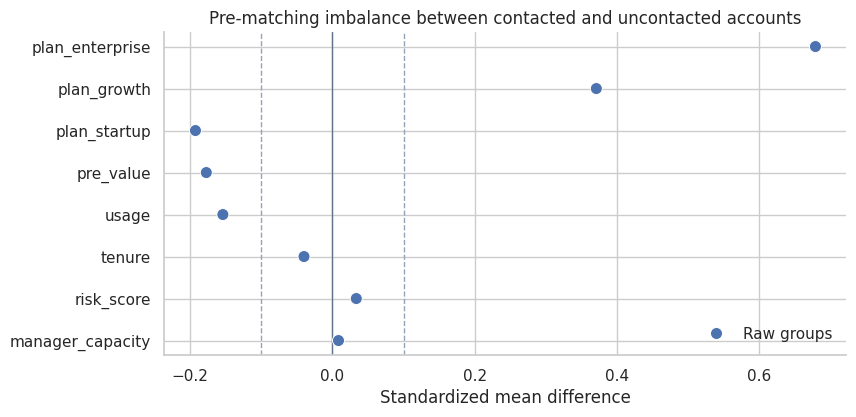

In [5]:
# Prepare the quantities used in the Pre-Matching Imbalance discussion.
plan_dummies = pd.get_dummies(df["plan"], prefix="plan", dtype=float)
balance_frame = pd.concat(
    [df[["treated", "risk_score", "usage", "pre_value", "tenure", "manager_capacity"]], plan_dummies],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]

raw_balance = standardized_mean_differences(balance_frame, balance_covariates)
smart_display(raw_balance)

plot_smd_comparison(
    {"Raw groups": raw_balance},
    title="Pre-matching imbalance between contacted and uncontacted accounts",
)

The raw groups are imbalanced. `risk_score`, `usage`, and plan composition differ across contacted and uncontacted accounts. Those are precisely the differences that can make the naive comparison misleading.

`manager_capacity` also differs because it affects who gets outreach. In this simulation, it does not affect potential outcomes. That distinction will matter when we compare matching strategies.

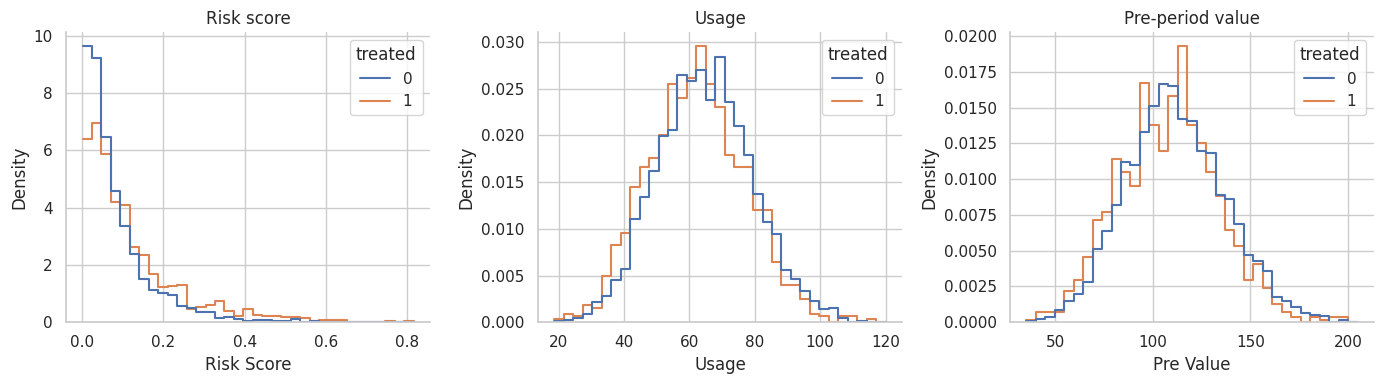

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in [
    (axes[0], "risk_score", "Risk score"),
    (axes[1], "usage", "Usage"),
    (axes[2], "pre_value", "Pre-period value"),
]:
    sns.histplot(
        data=df,
        x=col,
        hue="treated",
        stat="density",
        common_norm=False,
        bins=35,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(col.replace("_", " ").title())
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

The distributions overlap, but they are shifted. That is the setting where matching can be helpful. There are untreated accounts that resemble treated accounts, but we should not use every untreated account equally.

## 5. Estimate a Propensity Score for Matching

Matching can use many distance measures: exact matching, Mahalanobis distance, propensity-score distance, coarsened exact matching, genetic matching, and others. Here we start with a logistic propensity score because it is familiar and connects directly to the previous notebook.

Rosenbaum and Rubin (1983) showed why the propensity score can serve as a balancing score. Austin (2011) describes nearest-neighbor matching and caliper matching as common propensity-score methods.

In [7]:
# Fit the statistical model and collect estimates used in the following interpretation.
ps_model = smf.logit(
    "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
    data=df,
).fit(disp=False, maxiter=250)

df["ps"] = np.clip(ps_model.predict(df), 0.01, 0.99)
df["ps_logit"] = logit(df["ps"])

for col in ["pre_value", "tenure", "usage", "risk_score"]:
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std(ddof=0)

ps_summary = pd.DataFrame({
    "quantity": [
        "Minimum estimated propensity score",
        "Median estimated propensity score",
        "Maximum estimated propensity score",
        "Mean estimated score among contacted accounts",
        "Mean estimated score among uncontacted accounts",
    ],
    "value": [
        df["ps"].min(),
        df["ps"].median(),
        df["ps"].max(),
        df.loc[df["treated"] == 1, "ps"].mean(),
        df.loc[df["treated"] == 0, "ps"].mean(),
    ],
})

smart_display(ps_summary)

,quantity,value
0,Minimum estimated propensity score,0.078711
1,Median estimated propensity score,0.169663
2,Maximum estimated propensity score,0.579434
3,Mean estimated score among contacted accounts,0.212384
4,Mean estimated score among uncontacted accounts,0.181360


The score estimates how likely each account was to receive outreach based on observed customer covariates. It is not an outcome model and it is not the treatment effect.

We will use the logit of the propensity score for distance calculations because raw propensity scores compress distances near 0 and 1. A caliper on the logit scale is common in applied propensity-score matching discussions.

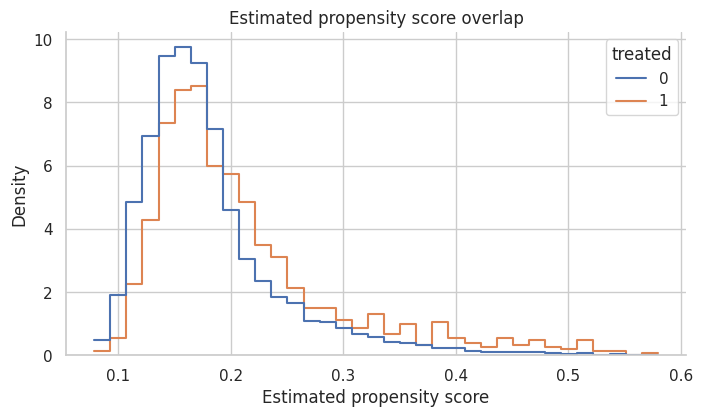

In [8]:
# Build the Interpretation plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.histplot(
    data=df,
    x="ps",
    hue="treated",
    stat="density",
    common_norm=False,
    bins=35,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("Estimated propensity score overlap")
ax.set_xlabel("Estimated propensity score")
sns.despine(ax=ax)
plt.show()

There is enough overlap to attempt matching, but contacted accounts have higher propensity scores on average. That is expected because outreach was targeted.

If the two groups barely overlapped, matching would not rescue the design. It would either discard many treated units or create poor matches.

## 6. Nearest-Neighbor Propensity-Score Matching

Nearest-neighbor matching assigns each treated unit to the control unit with the closest score.

We will use matching with replacement. That means the same control account can be reused for multiple treated accounts. This often improves match quality when the pool of good controls is limited, but it can make the effective control sample smaller.

In [9]:
# Assemble the Nearest-Neighbor Propensity-Score Matching summary table used for interpretation.
ps_pairs = nearest_neighbor_match(
    df,
    match_cols=["ps_logit"],
    ratio=1,
)

ps_match_summary = summarize_matched_pairs(df, ps_pairs, "1-to-1 PS nearest neighbor")
smart_display(pd.DataFrame([ps_match_summary]))
smart_display(ps_pairs.head())

,design,matched_treated,share_treated_matched,matched_control_rows,unique_controls_used,mean_matches_per_treated,att_hat,paired_se_teaching_approx,ci_low_teaching_approx,ci_high_teaching_approx,true_att_for_matched_treated,bias_vs_matched_att,mean_match_distance,p95_match_distance
0,1-to-1 PS nearest neighbor,1123,1.0,1123,928,1.0,3.432,0.369,2.709,4.156,3.961,-0.528,5.922e-04,0.002


,treated_index,control_index,distance,treated_outcome,control_outcome,treated_score,control_score
0,4,4045,4.917e-05,92.436,94.144,0.139,0.139
1,9,3319,1.259e-06,89.901,109.748,0.138,0.138
2,11,1957,5.513e-05,71.961,76.881,0.174,0.174
3,13,2143,2.127e-05,90.441,92.032,0.193,0.193
4,18,344,8.976e-05,94.918,96.595,0.137,0.137


Every contacted account is matched, and controls may be reused. The matched estimate is closer to the true ATT than the naive comparison, while matching on a scalar propensity score still needs balance diagnostics.

The important diagnostic is not just the estimated effect. We must ask: did the matched design balance the baseline covariates?

,design,max_abs_smd,mean_abs_smd
0,Raw groups,0.679,0.207
1,1-to-1 PS nearest neighbor,0.681,0.116


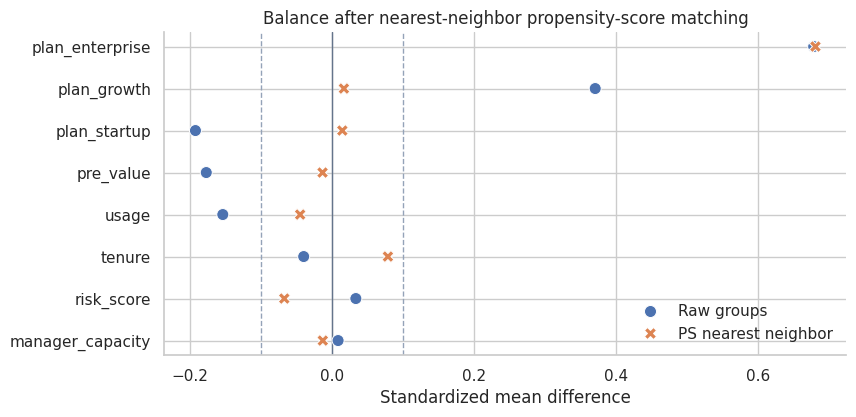

In [10]:
# Assemble the Interpretation summary table used for interpretation.
ps_weights = matching_weights(df, ps_pairs, ratio=1)
ps_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=ps_weights)

balance_summary = pd.DataFrame({
    "design": ["Raw groups", "1-to-1 PS nearest neighbor"],
    "max_abs_smd": [raw_balance["abs_smd"].max(), ps_balance["abs_smd"].max()],
    "mean_abs_smd": [raw_balance["abs_smd"].mean(), ps_balance["abs_smd"].mean()],
})

smart_display(balance_summary)

plot_smd_comparison(
    {"Raw groups": raw_balance, "PS nearest neighbor": ps_balance},
    title="Balance after nearest-neighbor propensity-score matching",
)

The matched design improves some covariates, but a single score can still leave important residual imbalance in finite samples. This is one reason matching should be judged by balance, not by the elegance of the method name.

King and Nielsen (2019) argue that propensity-score matching can sometimes increase imbalance, inefficiency, model dependence, and bias. The practical lesson is not "never use propensity scores." It is: inspect the design they actually create.

## 7. Calipers: Refusing Bad Matches

A caliper sets a maximum acceptable distance. If no control lies within the caliper, the treated unit is left unmatched.

This improves match quality but changes the target population. The estimand becomes the ATT among matched treated units, not necessarily the ATT among all treated units.

A common teaching rule is to use a caliper such as 0.2 standard deviations of the logit propensity score. The exact choice should be justified and sensitivity-checked.

In [11]:
# Build the summary table used to connect the calculation back to the design question.
logit_caliper = 0.2 * df["ps_logit"].std(ddof=0)

caliper_pairs = nearest_neighbor_match(
    df,
    match_cols=["ps_logit"],
    ratio=1,
    caliper_col="ps_logit",
    caliper=logit_caliper,
)

caliper_summary = summarize_matched_pairs(df, caliper_pairs, "1-to-1 PS caliper")
caliper_table = pd.DataFrame([
    {"quantity": "Logit propensity-score caliper", "value": logit_caliper},
    {"quantity": "Matched treated accounts", "value": caliper_summary["matched_treated"]},
    {"quantity": "Share of treated accounts matched", "value": caliper_summary["share_treated_matched"]},
])

smart_display(caliper_table)
smart_display(pd.DataFrame([caliper_summary]))

,quantity,value
0,Logit propensity-score caliper,0.081743
1,Matched treated accounts,1122.000000
2,Share of treated accounts matched,0.999110


,design,matched_treated,share_treated_matched,matched_control_rows,unique_controls_used,mean_matches_per_treated,att_hat,paired_se_teaching_approx,ci_low_teaching_approx,ci_high_teaching_approx,true_att_for_matched_treated,bias_vs_matched_att,mean_match_distance,p95_match_distance
0,1-to-1 PS caliper,1122,0.999,1122,928,1.0,3.424,0.369,2.7,4.148,3.961,-0.537,4.828e-04,0.001


In this dataset, the caliper discards very few treated accounts because close controls exist for almost everyone on the propensity-score scale. In other settings, a caliper may discard many treated units. That is not necessarily a failure; it may be honest evidence that the data cannot support the original target population.

Whenever a caliper drops units, report how many units were dropped and how the matched treated population differs from the original treated population.

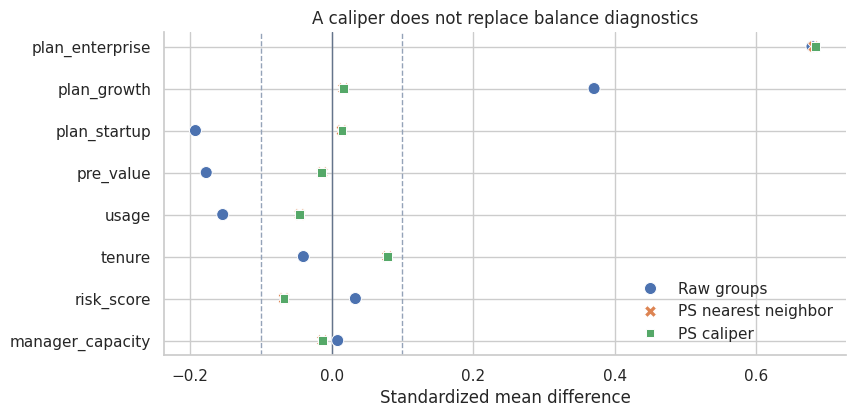

In [12]:
# Prepare the quantities used in the Interpretation discussion.
caliper_weights = matching_weights(df, caliper_pairs, ratio=1)
caliper_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=caliper_weights)

plot_smd_comparison(
    {
        "Raw groups": raw_balance,
        "PS nearest neighbor": ps_balance,
        "PS caliper": caliper_balance,
    },
    title="A caliper does not replace balance diagnostics",
)

A caliper controls distance on the score, but it does not guarantee that every individual covariate is balanced. This is a subtle but important point. The propensity score is useful because it is a balancing score in theory, but estimated scores and finite samples still require diagnostics.

## 8. Matching More Than One Control

Instead of one control per treated unit, we can match multiple controls. Ratio matching often reduces variance because each treated unit is compared to a more stable local control average.

The tradeoff is that the second or third nearest control is usually less similar than the first. More controls can reduce variance while increasing bias if the extra matches are poor.

In [13]:
# Build the summary table used to connect the calculation back to the design question.
ratio3_pairs = nearest_neighbor_match(
    df,
    match_cols=["ps_logit"],
    ratio=3,
    caliper_col="ps_logit",
    caliper=logit_caliper,
)
ratio3_summary = summarize_matched_pairs(df, ratio3_pairs, "1-to-3 PS caliper")

comparison_so_far = pd.DataFrame([
    {
        "design": "Naive treated-control difference",
        "matched_treated": df["treated"].sum(),
        "share_treated_matched": 1.0,
        "unique_controls_used": df.loc[df["treated"] == 0].shape[0],
        "att_hat": naive_effect,
        "true_att_for_matched_treated": true_att,
        "bias_vs_matched_att": naive_effect - true_att,
    },
    ps_match_summary,
    caliper_summary,
    ratio3_summary,
])

smart_display(comparison_so_far[[
    "design",
    "matched_treated",
    "share_treated_matched",
    "unique_controls_used",
    "mean_matches_per_treated",
    "att_hat",
    "true_att_for_matched_treated",
    "bias_vs_matched_att",
]])

,design,matched_treated,share_treated_matched,unique_controls_used,mean_matches_per_treated,att_hat,true_att_for_matched_treated,bias_vs_matched_att
0,Naive treated-control difference,1123,1.000000,4877,nan,1.969471,3.960713,-1.991241
1,1-to-1 PS nearest neighbor,1123,1.000000,928,1.000000,3.432411,3.960713,-0.528302
2,1-to-1 PS caliper,1122,0.999110,928,1.000000,3.424249,3.961486,-0.537236
3,1-to-3 PS caliper,1122,0.999110,2241,2.998217,3.908099,3.961486,-0.053387


Using three controls per treated account stabilizes the matched control outcome and uses more of the control pool. In this simulation it moves the estimate closer to the matched ATT.

The right ratio depends on overlap, match quality, and the bias-variance tradeoff. A careful analysis should show how conclusions change across reasonable matching specifications.

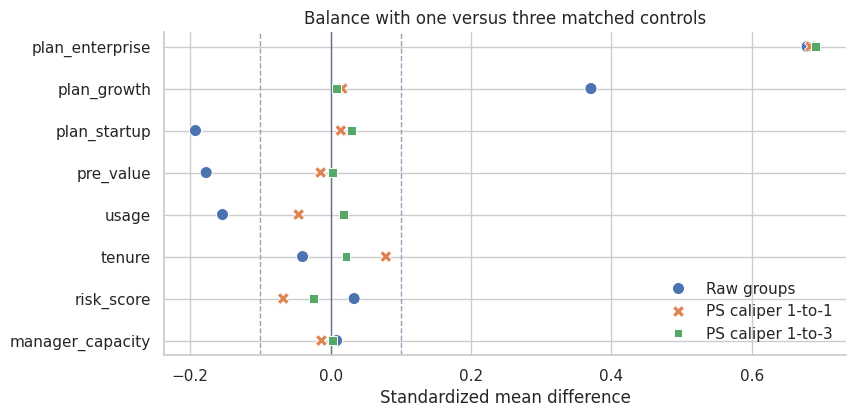

In [14]:
# Prepare the quantities used in the Interpretation discussion.
ratio3_weights = matching_weights(df, ratio3_pairs, ratio=3)
ratio3_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=ratio3_weights)

plot_smd_comparison(
    {
        "Raw groups": raw_balance,
        "PS caliper 1-to-1": caliper_balance,
        "PS caliper 1-to-3": ratio3_balance,
    },
    title="Balance with one versus three matched controls",
)

The 1-to-3 design changes both the estimate and the balance profile. Matching is a design choice, and design choices should be documented.

When two reasonable designs give materially different answers, that is a finding. It tells us the observational data are not giving a frictionless answer.

## 9. Exact Matching Plus Covariate Distance

Propensity-score matching is not the only option. We can require exact matches on an important categorical variable and then match on continuous covariates.

For customer-success outreach, plan tier may be a useful exact-match variable because enterprise, growth, and startup customers can differ operationally. Within each plan tier, we match on standardized pre-treatment value, tenure, usage, and risk.

,design,matched_treated,share_treated_matched,matched_control_rows,unique_controls_used,mean_matches_per_treated,att_hat,paired_se_teaching_approx,ci_low_teaching_approx,ci_high_teaching_approx,true_att_for_matched_treated,bias_vs_matched_att,mean_match_distance,p95_match_distance
0,Exact plan plus covariate NN,1123,1.0,1123,962,1.0,3.856,0.187,3.489,4.224,3.961,-0.104,0.31,0.645


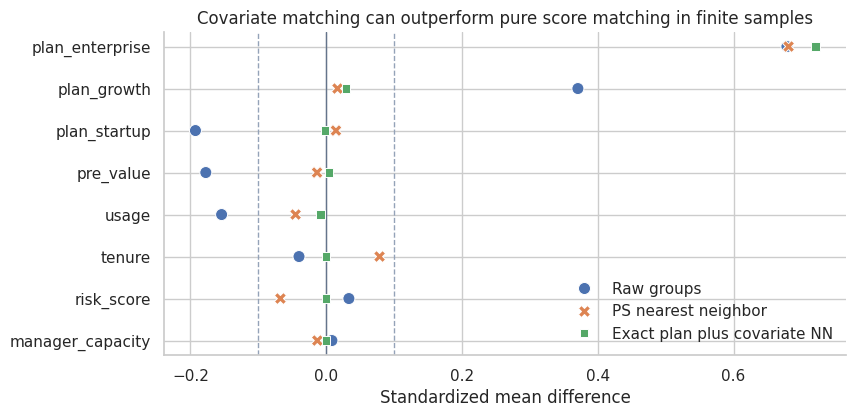

In [15]:
# Build the summary table used to connect the calculation back to the design question.
covariate_pairs = nearest_neighbor_match(
    df,
    match_cols=["pre_value_z", "tenure_z", "usage_z", "risk_score_z"],
    ratio=1,
    exact_cols=["plan"],
)

covariate_summary = summarize_matched_pairs(df, covariate_pairs, "Exact plan plus covariate NN")
covariate_weights = matching_weights(df, covariate_pairs, ratio=1)
covariate_balance = standardized_mean_differences(balance_frame, balance_covariates, weights=covariate_weights)

smart_display(pd.DataFrame([covariate_summary]))

plot_smd_comparison(
    {
        "Raw groups": raw_balance,
        "PS nearest neighbor": ps_balance,
        "Exact plan plus covariate NN": covariate_balance,
    },
    title="Covariate matching can outperform pure score matching in finite samples",
)

Exact matching on plan tier plus nearest-neighbor matching on standardized covariates improves balance in this example and produces an estimate closer to the true matched ATT.

This is why matching should not be reduced to one default recipe. The design should reflect domain structure. If plan tier defines very different customer contexts, forcing exact matches within plan may be more credible than allowing the propensity score to trade plan differences against other covariates.

## 10. Comparing Matching Designs

Now we collect the designs in one table. Remember that the true effects are available only because this is a simulation.

,design,matched_treated,share_treated_matched,unique_controls_used,mean_matches_per_treated,att_hat,true_att_for_matched_treated,bias_vs_matched_att,paired_se_teaching_approx
0,Naive treated-control difference,1123,1.000000,4877,nan,1.969471,3.960713,-1.991241,nan
1,1-to-1 PS nearest neighbor,1123,1.000000,928,1.000000,3.432411,3.960713,-0.528302,0.369059
2,1-to-1 PS caliper,1122,0.999110,928,1.000000,3.424249,3.961486,-0.537236,0.369298
3,1-to-3 PS caliper,1122,0.999110,2241,2.998217,3.908099,3.961486,-0.053387,0.311353
4,Exact plan plus covariate NN,1123,1.000000,962,1.000000,3.856493,3.960713,-0.104219,0.187474


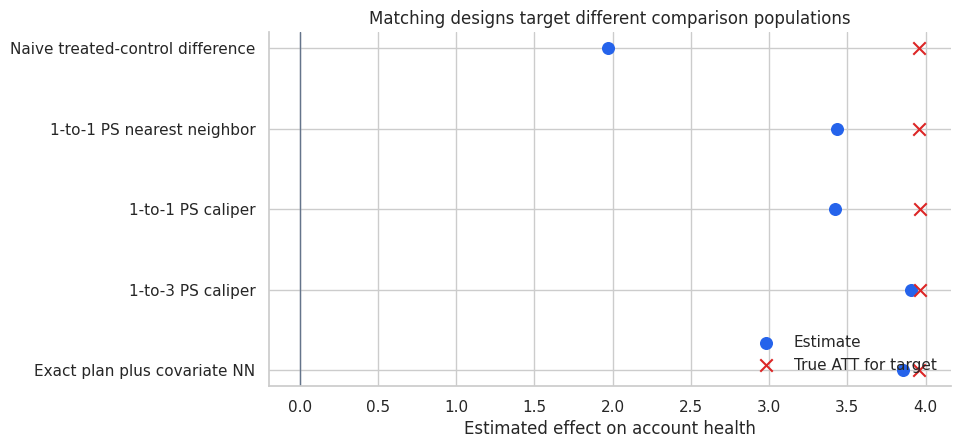

In [16]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
all_designs = pd.DataFrame([
    {
        "design": "Naive treated-control difference",
        "matched_treated": df["treated"].sum(),
        "share_treated_matched": 1.0,
        "matched_control_rows": np.nan,
        "unique_controls_used": df.loc[df["treated"] == 0].shape[0],
        "mean_matches_per_treated": np.nan,
        "att_hat": naive_effect,
        "paired_se_teaching_approx": np.nan,
        "ci_low_teaching_approx": np.nan,
        "ci_high_teaching_approx": np.nan,
        "true_att_for_matched_treated": true_att,
        "bias_vs_matched_att": naive_effect - true_att,
        "mean_match_distance": np.nan,
        "p95_match_distance": np.nan,
    },
    ps_match_summary,
    caliper_summary,
    ratio3_summary,
    covariate_summary,
])

smart_display(all_designs[[
    "design",
    "matched_treated",
    "share_treated_matched",
    "unique_controls_used",
    "mean_matches_per_treated",
    "att_hat",
    "true_att_for_matched_treated",
    "bias_vs_matched_att",
    "paired_se_teaching_approx",
]])

fig, ax = plt.subplots(figsize=(8.8, 4.6))
plot_df = all_designs.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_df))
ax.scatter(plot_df["att_hat"], y, color="#2563eb", s=70, label="Estimate")
ax.scatter(plot_df["true_att_for_matched_treated"], y, color="#dc2626", marker="x", s=80, label="True ATT for target")
ax.axvline(0, color="#64748b", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["design"])
ax.set_xlabel("Estimated effect on account health")
ax.set_title("Matching designs target different comparison populations")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax)
plt.show()

The best-looking estimate is not enough. We care about balance, overlap, target population, and the sensitivity of conclusions to design choices.

The simple paired standard error in the table is a teaching approximation. In real matched analyses, uncertainty estimation can require more care because matching is a data-dependent preprocessing step, controls can be reused, and calipers can change the target population.

## 11. Visualizing Matched Pairs

A matched design should be inspectable. One simple diagnostic is the distribution of match distances. Another is a plot of treated and matched control scores.

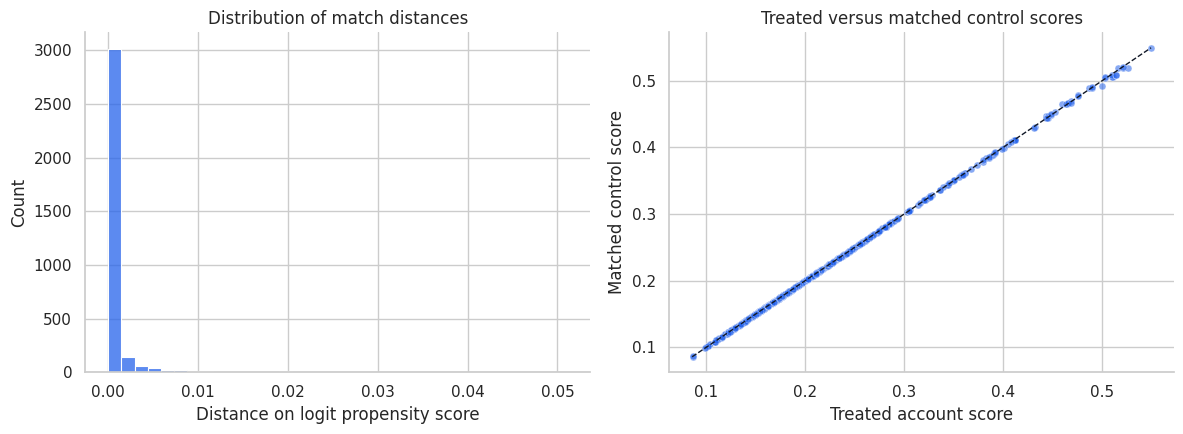

In [17]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
matched_plot = ratio3_pairs.copy()
matched_plot["score_gap"] = abs(matched_plot["treated_score"] - matched_plot["control_score"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(matched_plot["distance"], bins=35, color="#2563eb", ax=axes[0])
axes[0].set_title("Distribution of match distances")
axes[0].set_xlabel("Distance on logit propensity score")

sample_pairs = matched_plot.sample(700, random_state=14)
sns.scatterplot(
    data=sample_pairs,
    x="treated_score",
    y="control_score",
    alpha=0.55,
    s=25,
    color="#2563eb",
    ax=axes[1],
)
lo = min(sample_pairs["treated_score"].min(), sample_pairs["control_score"].min())
hi = max(sample_pairs["treated_score"].max(), sample_pairs["control_score"].max())
axes[1].plot([lo, hi], [lo, hi], color="#111827", linestyle="--", linewidth=1)
axes[1].set_title("Treated versus matched control scores")
axes[1].set_xlabel("Treated account score")
axes[1].set_ylabel("Matched control score")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Most matched controls are very close on the propensity-score scale. That is useful, but it is only one diagnostic. A good score match can still leave imbalance on individual covariates, especially if the score model is misspecified or the sample is finite.

This is why the balance plot is the central diagnostic, not the match-distance histogram.

## 12. Matching and Outcome Modeling

Matching does not forbid outcome modeling. In fact, a common workflow is:

1. Match to improve overlap and balance.
2. Fit a simple outcome model on the matched sample to adjust remaining imbalance.

This is sometimes called matching as preprocessing. The key is that matching reduces dependence on strong parametric assumptions; it does not remove the need to think about the outcome model.

In [18]:
# Fit the statistical model and collect estimates used in the following interpretation.
matched_ids = np.flatnonzero(covariate_weights > 0)
matched_df = df.loc[matched_ids].copy()
matched_df["match_weight"] = covariate_weights[matched_ids]

matched_outcome_model = smf.wls(
    "outcome ~ treated + pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
    data=matched_df,
    weights=matched_df["match_weight"],
).fit(cov_type="HC3")

unmatched_outcome_model = smf.ols(
    "outcome ~ treated + pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
    data=df,
).fit(cov_type="HC3")

model_comparison = pd.DataFrame({
    "analysis": [
        "Naive difference",
        "Matched difference from exact-plan covariate NN",
        "Outcome regression on full data",
        "Outcome regression after matching",
    ],
    "estimate": [
        naive_effect,
        covariate_summary["att_hat"],
        unmatched_outcome_model.params["treated"],
        matched_outcome_model.params["treated"],
    ],
})
model_comparison["reference_true_att"] = true_att
model_comparison["bias_vs_true_att"] = model_comparison["estimate"] - true_att

smart_display(model_comparison)

,analysis,estimate,reference_true_att,bias_vs_true_att
0,Naive difference,1.969471,3.960713,-1.991241
1,Matched difference from exact-plan covariate NN,3.856493,3.960713,-0.104219
2,Outcome regression on full data,3.943956,3.960713,-0.016757
3,Outcome regression after matching,3.932035,3.960713,-0.028678


The matched difference and the post-matching regression are close in this simulation. In real data, the post-matching regression can help adjust small residual imbalance, but it should not be used to hide a poor matched design.

If matching produces bad balance, fix the matching design first. Outcome regression after a bad match is not a design rescue mission.

## 13. Common Matching Choices

| Choice | What it controls | Tradeoff |
|---|---|---|
| Exact matching | Requires identical values on selected variables | Strong design guarantee, but can drop many units. |
| Nearest-neighbor matching | Finds closest controls by a distance metric | Easy to explain, but can create poor matches without calipers. |
| Caliper matching | Refuses matches that are too far away | Improves match quality, changes target population if units are dropped. |
| Matching with replacement | Allows strong controls to be reused | Better matches, smaller effective control sample. |
| Matching without replacement | Uses each control once | Larger unique control set, potentially worse later matches. |
| Ratio matching | Uses multiple controls per treated unit | Lower variance if extra controls are good, higher bias if they are poor. |
| Exact plus distance matching | Combines domain constraints with continuous-distance matching | Often credible, but requires thoughtful domain choices. |

Caliendo and Kopeinig (2008) emphasize that applied propensity-score matching requires many implementation choices. Those choices are not clerical. They define the design.

## 14. Matching Failure Modes

Matching can fail in several ways:

- **No overlap**: treated units have no comparable controls.
- **Bad distance metric**: the matching score ignores important confounders.
- **Over-compression**: propensity-score matching balances the score but not individual covariates.
- **Post-treatment variables**: matching on variables affected by treatment changes the estimand or creates bias.
- **Hidden confounding**: matching balances observed variables only.
- **Unreported pruning**: dropping unmatched units changes the target population without telling the reader.
- **Outcome-driven design**: changing matches after seeing results overfits the design to the conclusion.

A matched sample should be treated as a constructed design. Its credibility comes from what it balances and what population it represents.

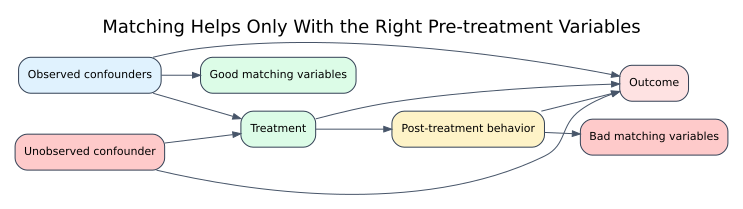

In [19]:
# Organize the calculation into readable steps for the lecture narrative.
failure_edges = [
    ("Observed confounders", "Treatment"),
    ("Observed confounders", "Outcome"),
    ("Unobserved confounder", "Treatment"),
    ("Unobserved confounder", "Outcome"),
    ("Treatment", "Post-treatment behavior"),
    ("Post-treatment behavior", "Outcome"),
    ("Treatment", "Outcome"),
    ("Observed confounders", "Good matching variables"),
    ("Post-treatment behavior", "Bad matching variables"),
]

failure_colors = {
    "Observed confounders": "#e0f2fe",
    "Unobserved confounder": "#fecaca",
    "Treatment": "#dcfce7",
    "Outcome": "#fee2e2",
    "Post-treatment behavior": "#fef3c7",
    "Good matching variables": "#dcfce7",
    "Bad matching variables": "#fecaca",
}

smart_display(make_dag(failure_edges, "Matching Helps Only With the Right Pre-treatment Variables", failure_colors))

Matching on observed pre-treatment confounders can improve a design. Matching on post-treatment behavior is a bad-control problem. Failing to measure an important confounder remains an identification problem.

Matching is powerful because it makes comparisons tangible, but it cannot make an impossible comparison possible.

## 15. Matching Workflow for Industry Projects

A professional matching readout should include:

| Step | Question | What to show |
|---|---|---|
| 1. Estimand | Are we targeting ATT, ATE, or a matched population? | Causal question and target population. |
| 2. Matching variables | Which pre-treatment variables define comparability? | Timing table, DAG, feature list. |
| 3. Distance metric | How are units compared? | Propensity score, exact variables, covariate distance. |
| 4. Matching rules | Replacement, ratio, caliper, exact constraints? | Design specification table. |
| 5. Unit retention | Who was dropped? | Share of treated and controls retained. |
| 6. Balance | Did matching improve covariate balance? | SMD table and plot before/after. |
| 7. Outcome analysis | What is the matched effect estimate? | ATT estimate, uncertainty, sensitivity. |
| 8. Robustness | Do reasonable designs agree? | Compare calipers, ratios, distance choices. |
| 9. Limitations | What remains unaddressed? | Hidden confounding, measurement error, interference. |

This structure lets readers see the estimate and the design evidence behind it.

## Key Takeaways

- Matching is a design-stage tool for constructing comparable treated and untreated groups.
- Matching often targets the ATT because it starts with treated units and finds controls for them.
- Matching quality must be judged by balance and overlap, not by the method name.
- Propensity-score matching is useful in some settings, but it can still leave covariate imbalance.
- Calipers improve match quality but may change the target population by dropping treated units.
- Matching with replacement improves local match quality but can reuse a small set of controls heavily.
- Exact matching on domain-critical variables can make the design more credible.
- Matching does not solve unmeasured confounding or bad-control problems.

## References

Austin, P. C. (2011). An introduction to propensity score methods for reducing the effects of confounding in observational studies. *Multivariate Behavioral Research, 46*(3), 399-424. https://doi.org/10.1080/00273171.2011.568786

Caliendo, M., & Kopeinig, S. (2008). Some practical guidance for the implementation of propensity score matching. *Journal of Economic Surveys, 22*(1), 31-72. https://doi.org/10.1111/j.1467-6419.2007.00527.x

Ho, D. E., Imai, K., King, G., & Stuart, E. A. (2007). Matching as nonparametric preprocessing for reducing model dependence in parametric causal inference. *Political Analysis, 15*(3), 199-236. https://doi.org/10.1093/pan/mpl013

King, G., & Nielsen, R. A. (2019). Why propensity scores should not be used for matching. *Political Analysis, 27*(4), 435-454. https://doi.org/10.1017/pan.2019.11

Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41-55. https://doi.org/10.1093/biomet/70.1.41

Stuart, E. A. (2010). Matching methods for causal inference: A review and a look forward. *Statistical Science, 25*(1), 1-21. https://doi.org/10.1214/09-STS313